# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE

for name, model in base_models.items():
    model.fit(X_train, y_train)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    baseline_results[name] = (np.mean(score), np.std(score))

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [4]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                         ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C' : [0.1, 1, 10, 100],
    'svm__gamma' : ['scale', 0.01, 0.001],
    'svm__kernel' : ['rbf','linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(svm_pipe, svm_param_grid, scoring='f1_macro', n_jobs=-1, cv=5)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [5]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_search_results = pd.DataFrame(svm_grid_search.cv_results_)
display(svm_search_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values(by='rank_test_score').head(10))

,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    # YOUR CODE HERE
    'n_estimators' : randint(50, 500),                         
    'max_depth' : [randint(2, 20), None],                     
    'min_samples_split' : randint(2, 20),                       
    'max_features' : ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_random_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_param_dist, n_iter=50, cv=5, scoring='f1_macro', random_state=42, n_jobs=-1)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': None, 'max_features': 0.5, 'min_samples_split': 8, 'n_estimators': 477}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [7]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
display(pd.DataFrame(
    {
        'SVM baseline' : {
            'CV F1 (mean±std)' : f"{baseline_results['SVM'][0]:.4f}±{baseline_results['SVM'][1]:.4f}", 
            'Test F1' : f1_score(y_test, base_models['SVM'].predict(X_test))
            },
        'SVM Grid Search' : {
            'CV F1 (mean±std)' : f"{svm_search_results.iloc[svm_grid_search.best_index_]['mean_test_score']:.4f}±{svm_search_results.iloc[svm_grid_search.best_index_]['std_test_score']:.4f}", 
            'Test F1' : f1_score(y_test, svm_grid_search.best_estimator_.predict(X_test))
            },
        'RF baseline' : {
            'CV F1 (mean±std)' : f"{baseline_results['RandomForest'][0]:.4f}±{baseline_results['RandomForest'][1]:.4f}", 
            'Test F1' : f1_score(y_test, base_models['RandomForest'].predict(X_test))
            },
        'RF Random Search' : {
            'CV F1 (mean±std)' : f"{rf_random_search.cv_results_['mean_test_score'][rf_random_search.best_index_]:.4f}±{rf_random_search.cv_results_['std_test_score'][rf_random_search.best_index_]:.4f}", 
            'Test F1' : f1_score(y_test, rf_random_search.best_estimator_.predict(X_test))
            }
    }
).T)

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

,CV F1 (mean±std),Test F1
SVM baseline,0.9694±0.0193,0.986111
SVM Grid Search,0.9786±0.0176,0.986111
RF baseline,0.9504±0.0255,0.965517
RF Random Search,0.9554±0.0175,0.965517


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

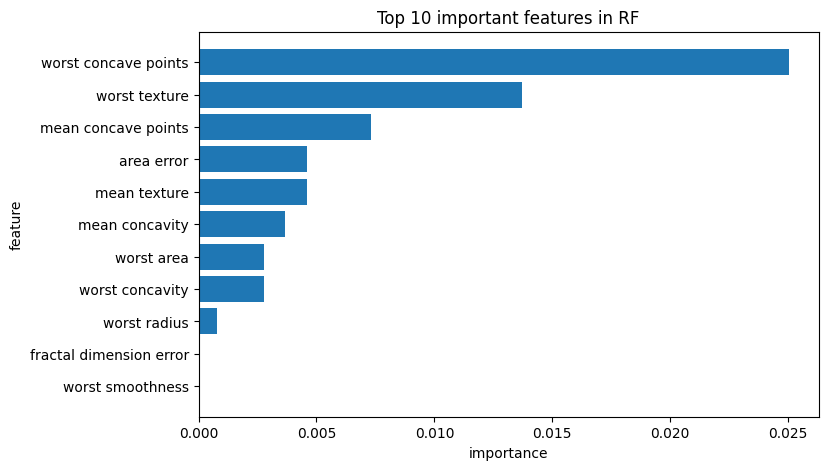

In [8]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42, scoring='f1_macro')


# Построим bar plot топ-10 признаков
pi_result_top_indices = np.argsort(pi_result['importances_mean'])[-11:]
ax = plt.figure(figsize=(8, 5)).add_subplot()
ax.barh(y=X.columns[pi_result_top_indices], width=pi_result['importances_mean'][pi_result_top_indices])
ax.set_title('Top 10 important features in RF')
ax.set_xlabel('importance')
ax.set_ylabel('feature')
plt.show()


In [9]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result_comp = pd.DataFrame([[pi_res, rf_res] for pi_res, rf_res in zip(X.columns[np.argsort(pi_result['importances_mean'])[:-6:-1]], X.columns[np.argsort(best_rf.feature_importances_)[:-6:-1]])])
pi_result_comp.columns = ['permutation_importance', 'feature_importance']
pi_result_comp.index = list(range(1, 6))
display(pi_result_comp)

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

,permutation_importance,feature_importance
1,worst concave points,worst perimeter
2,worst texture,worst concave points
3,mean concave points,worst radius
4,area error,worst area
5,mean texture,mean concave points


### Ответы на воросы
* Порядок признаков не совпадает, потому что feature_importance_ считается на основе критерия Джини, а permutation_importance считается совсем другим способом.
* Признаки могут иметь высокий PI и низкую встроенную важность и наоборот, потому что могут быть скореллированы с другими признаками, то есть если признаки скореллированы, то PI у них будет низкий, а feature importance может быть высоким, есди деревья будут выбирать их достаточно часто для разделения выборки. Обратная ситуация возникает если деревья будут часто выбирать только один из скореллированных признаков на верхних узлах, поэтому у другого признака, который деревья будут выбирать для разделения редче и на более нижних узлах будет маленький feature_inportance, но т.к. узлы нижние, то PI будет высоким.

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

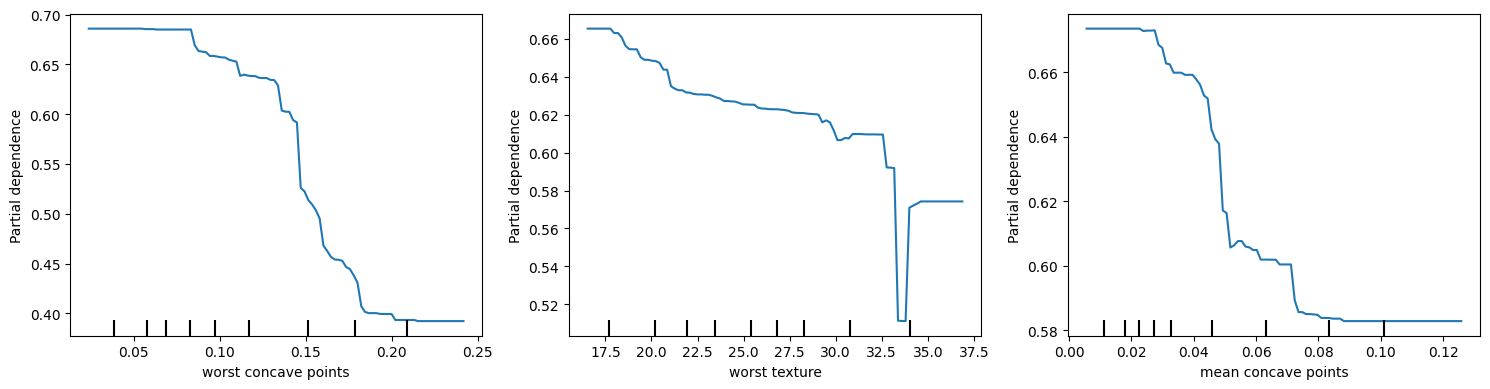

In [10]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = np.argsort(pi_result['importances_mean'])[:-4:-1]

# Постройте PDP
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
for ax, i in zip(axes, range(0, 3)):
    PartialDependenceDisplay.from_estimator(estimator=best_rf, X=X_train, features=[top3_idx[i]], kind='average', ax=ax, random_state=42)
plt.tight_layout()
plt.show()

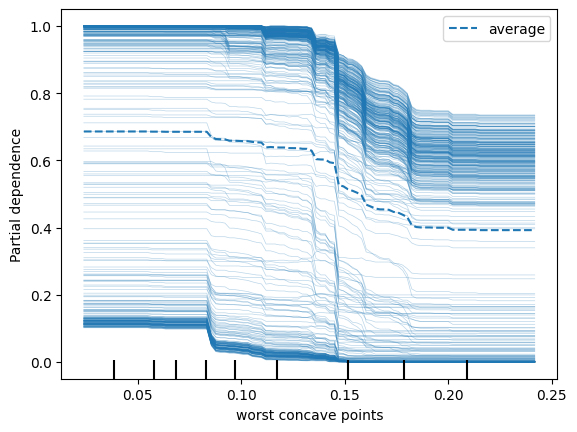

In [11]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)    ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
ax = plt.figure().add_subplot()
PartialDependenceDisplay.from_estimator(best_rf, X_train, [top3_idx[0]], kind='both', ax=ax, random_state=42)
plt.show()

### Ответ на ворос
* Эффект почти для всех объектов однороден.

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [12]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap
shap.initjs()

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
print(shap_values.shape)

(114, 30, 2)


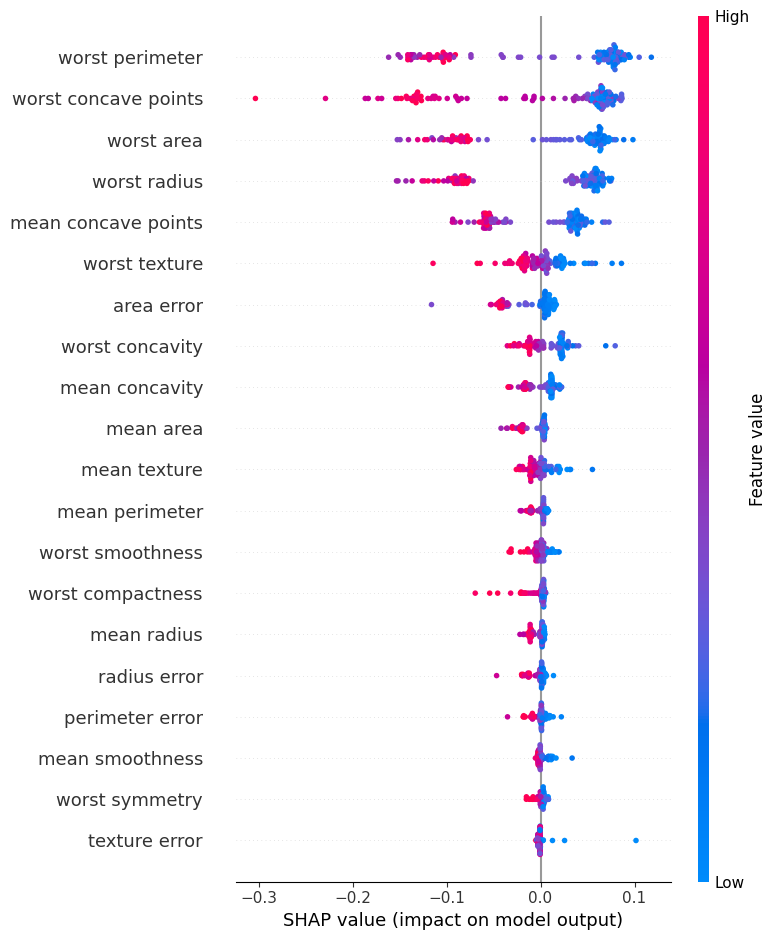

In [13]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
shap.summary_plot(shap_values[:, :, 1], X_test)

### Ответы на воросы
* Самыми важными по SHAP оказались worst perimeter, worst concave points и worst area.
* Получилось что далеко не все признаки которые находятся в топе по PI, являются самыми важными в среднем по SHAP.

In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
shap.force_plot(explainer.expected_value[1], shap_values[errors[0], :, 1], X_test.iloc[errors[0]])

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


### Ответ на ворос
* В ошибке виноваты самые важные признаки по SHAP (1, 3 и 4 из самых важных).

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [15]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

f1 score for leaky RF: 1.0


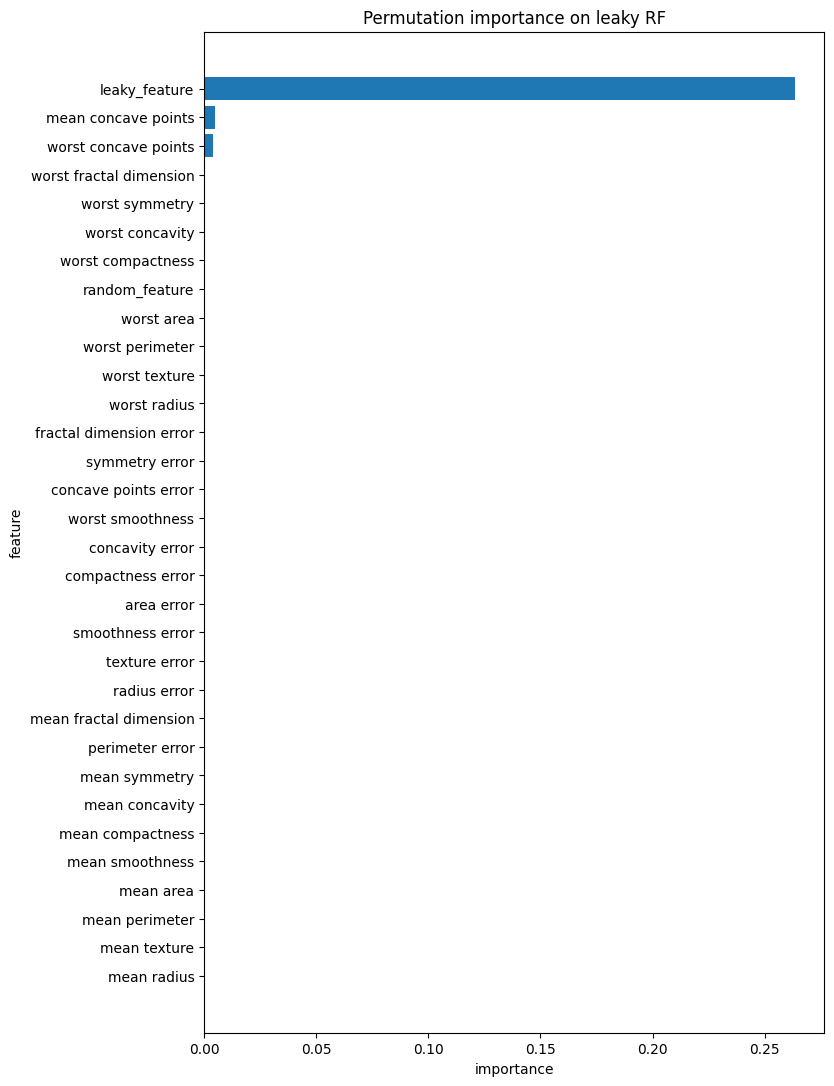

In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_leaky = RandomForestClassifier(random_state=42)
rf_leaky.fit(X_train_ext, y_train)
print(f"f1 score for leaky RF: {f1_score(y_test, rf_leaky.predict(X_test_ext))}")

pi_leaky_result = permutation_importance(rf_leaky, X_test_ext, y_test, n_repeats=10, random_state=42, scoring='f1_macro')

# Построим bar plot топ-10 признаков
pi_leaky_result_indices = np.argsort(pi_leaky_result['importances_mean'])
ax = plt.figure(figsize=(8, 13)).add_subplot()
ax.barh(y=X_train_ext.columns[pi_leaky_result_indices], width=pi_leaky_result['importances_mean'][pi_leaky_result_indices])
ax.set_title('Permutation importance on leaky RF')
ax.set_xlabel('importance')
ax.set_ylabel('feature')
plt.show()

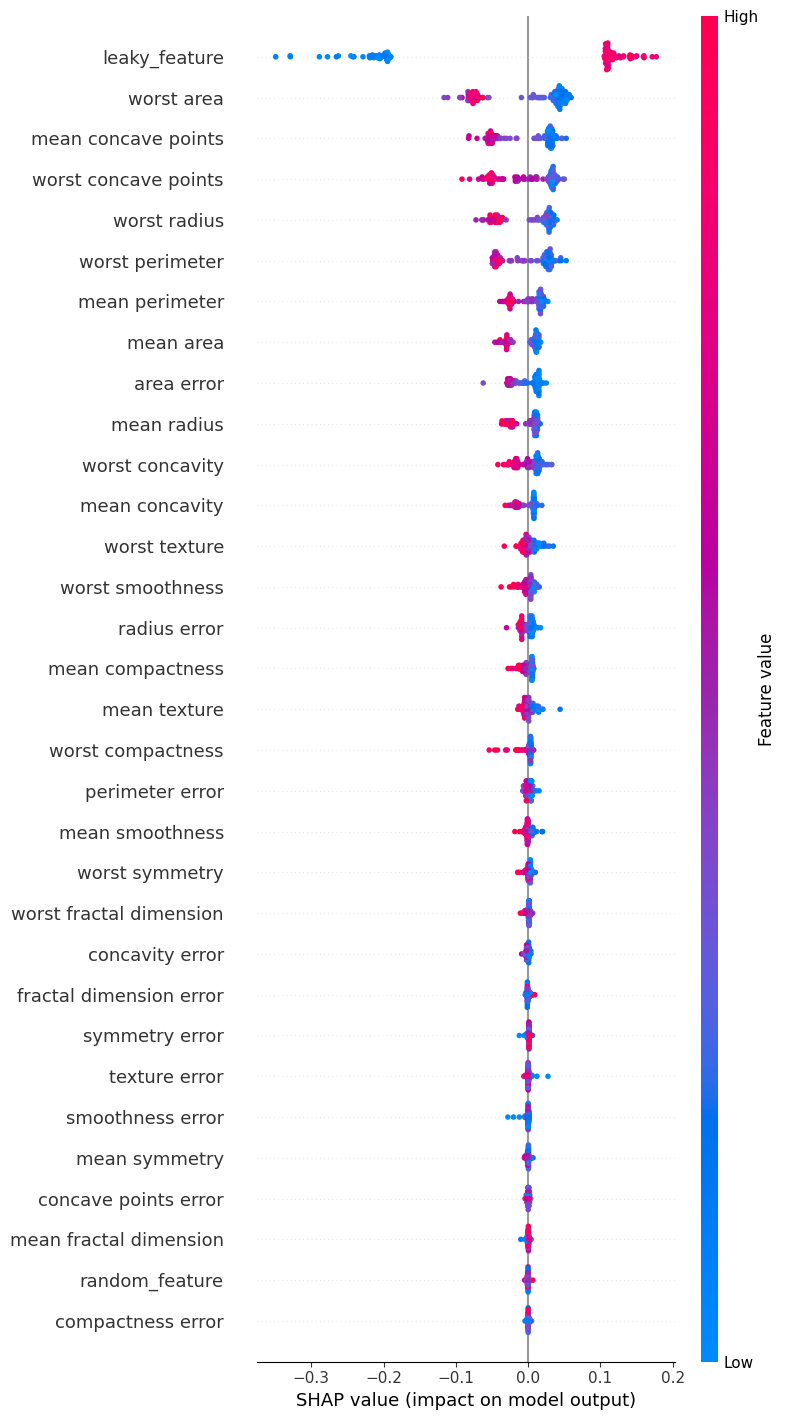

In [17]:
leaky_explainer = shap.TreeExplainer(rf_leaky)
leaky_shap_values = leaky_explainer.shap_values(X_test_ext)
shap.summary_plot(leaky_shap_values[:, :, 1], X_test_ext, max_display=32)

### Ответы на воросы
* У leaky_feature очень высокий PI потому что лес обучился так, что делал предсказания почти только на основе этого признака (потому что признак близок к таргету), то есть если переставить этот признак, то все ломается. Метрика f1 очевидно выросла на тесте, потому что в тесте есть колонка, которая почти точно равна таргету.
* leaky_feature находится выше всех признаков в summary_plot, причем его вклад знасительно больше чем у остальных.
* Можно сказать что random_feature шумовой, потому что во-первых у него почти нулевой PI (если перемешать шум, то скорее всего получится шум, то есть для модели ничего не изменилось), во-вторых по SHAP он почти ничего не вносит в предсказание модели.

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [18]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
display(pd.DataFrame(
    {
        'SVM baseline' : {
            'CV F1 (mean±std)' : f"{baseline_results['SVM'][0]:.4f}±{baseline_results['SVM'][1]:.4f}", 
            'Test F1' : f1_score(y_test, base_models['SVM'].predict(X_test)),
            'Выводы' : 'Одинаково с SVM Grid Search на тесте.'
            },
        'SVM Grid Search' : {
            'CV F1 (mean±std)' : f"{svm_search_results.iloc[svm_grid_search.best_index_]['mean_test_score']:.4f}±{svm_search_results.iloc[svm_grid_search.best_index_]['std_test_score']:.4f}", 
            'Test F1' : f1_score(y_test, svm_grid_search.best_estimator_.predict(X_test)),
            'Выводы' : 'Слегка лучше в cv, чем baseline.'
            },
        'RF baseline' : {
            'CV F1 (mean±std)' : f"{baseline_results['RandomForest'][0]:.4f}±{baseline_results['RandomForest'][1]:.4f}", 
            'Test F1' : f1_score(y_test, base_models['RandomForest'].predict(X_test)),
            'Выводы' : 'Хуже чем SVM для этой задачи.'
            },
        'RF Random Search' : {
            'CV F1 (mean±std)' : f"{rf_random_search.cv_results_['mean_test_score'][rf_random_search.best_index_]:.4f}±{rf_random_search.cv_results_['std_test_score'][rf_random_search.best_index_]:.4f}", 
            'Test F1' : f1_score(y_test, rf_random_search.best_estimator_.predict(X_test)),
            'Выводы' : 'Не сильно лучше чем baseline, одинаково на тесте'
            }
    }
).T)

,CV F1 (mean±std),Test F1,Выводы
SVM baseline,0.9694±0.0193,0.986111,Одинаково с SVM Grid Search на тесте.
SVM Grid Search,0.9786±0.0176,0.986111,"Слегка лучше в cv, чем baseline."
RF baseline,0.9504±0.0255,0.965517,Хуже чем SVM для этой задачи.
RF Random Search,0.9554±0.0175,0.965517,"Не сильно лучше чем baseline, одинаково на тесте"


### Ответы на воросы
* В данной задаче примененный тюнинг не слишком сильно улучшил модели (Единственное значительное улучшение было у стандартного отклонения у RF).
* Признаки не совсем совпадают (большинство лучших признаков по PI имеют высокие позиции и в SHAP, однако обратное неверно). Так происходит потому что признаки скореллированы и SHAP не принижает их значения в отличие от PI.
* Без PipeLine было бы неудобно подбирать парамеры отдельно для скейлера и самой модели (в этом ноутбуке итак в целом этого не было), да и в целом применять скейлер отдельно от модели неудобно, особенно когда нужно поменять датасет на другой или делать много предсказаний.
* Сначала я бы сдела EDA, удалил бы сильно скореллированные признаки, а затем уже применял бы эти метрики для моделей.

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [19]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")